In [1]:
from datetime import datetime
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchsummary import summary
import matplotlib.pyplot as plt

#### Loading the Data

In [2]:
training_data = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor()
)
test_data = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor()
)
print(training_data)
print(test_data)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ../data
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset MNIST
    Number of datapoints: 10000
    Root location: ../data
    Split: Test
    StandardTransform
Transform: ToTensor()


In [3]:
train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)

In [4]:
data_train, labels_train = next(iter(train_dataloader))
print(f"Feature batch shape: {data_train.shape}")
print(f"Labels batch shape: {labels_train.shape}")

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


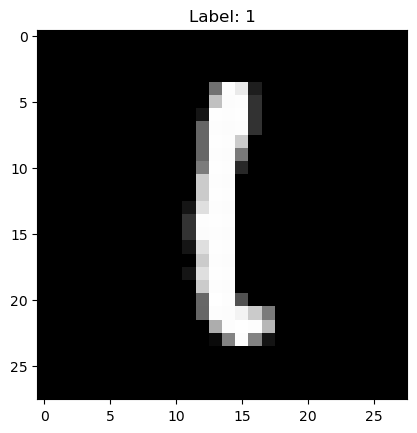

In [5]:
img = data_train[0].squeeze()
label = labels_train[0]
plt.imshow(img, cmap="gray")
plt.title(f"Label: {label}")
plt.show()

#### Multinomial Logistic Regression


##### Model

In [6]:
class LogisticRegression(torch.nn.Module):
    
    def __init__(self):
        super(LogisticRegression, self).__init__()
        self.flatten = torch.nn.Flatten()
        self.linear  = torch.nn.Linear(28*28,10)
    
    def forward(self, x):
        z = self.linear(self.flatten(x))
        return z


In [7]:
model = LogisticRegression()
print(model)

LogisticRegression(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Linear(in_features=784, out_features=10, bias=True)
)


In [8]:
summary(model, (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                   [-1, 10]           7,850
Total params: 7,850
Trainable params: 7,850
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.03
Estimated Total Size (MB): 0.04
----------------------------------------------------------------


##### Cost

In [9]:
cost_ce = torch.nn.CrossEntropyLoss()

##### Training

In [10]:
import math
def plot_training(nepochs, cost_hist, cost_hist_test, acc_hist, acc_hist_test):
    plt.figure(1)
    plt.plot(torch.arange(nepochs), cost_hist, "-")
    plt.plot(torch.arange(nepochs), cost_hist_test, "r-")
    mincost = max(max(cost_hist),1.0)
    plt.xlabel("Epoch")
    plt.xlim(0,nepochs)
    plt.ylim(0,mincost)
    plt.title("Cross-Entropy Cost")
    plt.figure(2)
    plt.plot(torch.arange(nepochs), acc_hist,"-")
    plt.plot(torch.arange(nepochs), acc_hist_test,"r-")
    minacc = min(min(acc_hist),0.8)
    plt.xlabel("Epoch")
    plt.xlim(0,nepochs)
    plt.ylim(minacc,1)
    plt.title("Accuracy")

In [15]:
nepochs = 50
learning_rate = 0.2

cost_hist = []
cost_hist_test = []
acc_hist = []
acc_hist_test = []

model = LogisticRegression()
cost_ce = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

Xtrain, Ytrain = next(iter(DataLoader(training_data, batch_size=64, shuffle=True)))
Xtest, Ytest = next(iter(DataLoader(test_data, batch_size=10000, shuffle=True)))

for epoch in range(nepochs):
    pred = model(Xtrain)
    loss = cost_ce(pred, Ytrain)
    cost = loss.item()
    acc = (pred.argmax(dim=1) == Ytrain).type(torch.float).mean().item()
    # gradient, parameter update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    with torch.no_grad():
        pred = model(Xtest)
        cost_test = cost_ce(pred, Ytest).item()
        acc_test = (pred.argmax(dim=1) == Ytest).type(torch.float).mean().item()
    print("Epoch %i: %f, %f, %f, %f"%(epoch, cost, acc, cost_test, acc_test))
    cost_hist.append(cost)
    cost_hist_test.append(cost_test)
    acc_hist.append(acc)
    acc_hist_test.append(acc_test)


Epoch 0: 2.309605, 0.062500, 2.141879, 0.269300
Epoch 1: 1.933606, 0.453125, 1.983383, 0.426800
Epoch 2: 1.661216, 0.703125, 1.849347, 0.514300
Epoch 3: 1.440143, 0.812500, 1.737678, 0.552400
Epoch 4: 1.259905, 0.875000, 1.644804, 0.573800
Epoch 5: 1.112319, 0.921875, 1.567284, 0.590400
Epoch 6: 0.990670, 0.953125, 1.502175, 0.606900
Epoch 7: 0.889561, 0.968750, 1.447106, 0.622400
Epoch 8: 0.804738, 0.984375, 1.400202, 0.632800
Epoch 9: 0.732893, 0.984375, 1.359996, 0.642100
Epoch 10: 0.671475, 0.984375, 1.325324, 0.649200
Epoch 11: 0.618511, 0.984375, 1.295260, 0.654300
Epoch 12: 0.572469, 0.984375, 1.269054, 0.657700
Epoch 13: 0.532148, 0.984375, 1.246093, 0.663000
Epoch 14: 0.496597, 1.000000, 1.225875, 0.664700
Epoch 15: 0.465057, 1.000000, 1.207985, 0.666300
Epoch 16: 0.436915, 1.000000, 1.192081, 0.669300
Epoch 17: 0.411673, 1.000000, 1.177878, 0.672000
Epoch 18: 0.388923, 1.000000, 1.165141, 0.673100
Epoch 19: 0.368329, 1.000000, 1.153671, 0.674900
Epoch 20: 0.349609, 1.000000, 

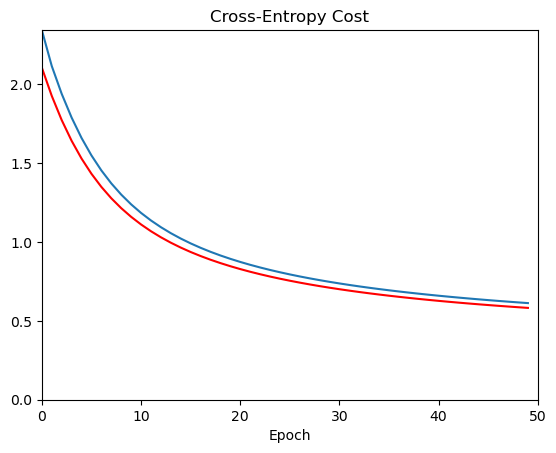

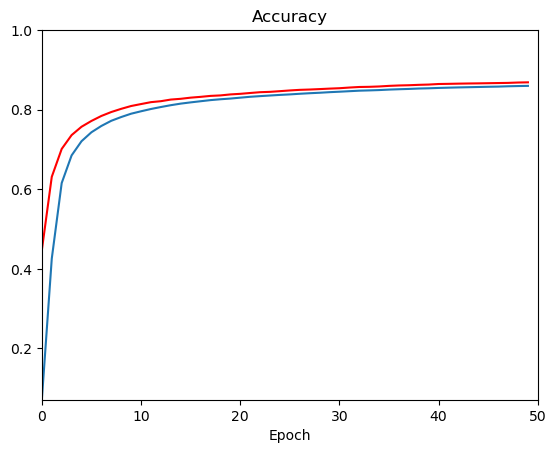

In [13]:
plot_training(nepochs, cost_hist, cost_hist_test, acc_hist, acc_hist_test)

#### Stochastic Gradient Descent

In [14]:
nbatch = 64
nepochs = 10
learning_rate = 0.01

cost_hist = []
cost_hist_test = []
acc_hist = []
acc_hist_test = []

model = LogisticRegression()
cost_ce = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

training_loader = DataLoader(training_data, batch_size=nbatch, shuffle=True)
test_loader = DataLoader(test_data, batch_size=10000, shuffle=True)
size = len(training_loader.dataset)
nbatches = len(training_loader)

Xtest, Ytest = next(iter(test_loader))

for epoch in range(nepochs):
    cost, acc = 0.0, 0.0
    for batch, (X, Y) in enumerate(training_loader):
        pred = model(X)
        loss = cost_ce(pred, Y)
        cost += loss.item()
        acc += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()

        # gradient, parameter update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    cost /= nbatches
    acc /= size
    
    with torch.no_grad():
        pred = model(Xtest)
        cost_test = cost_ce(pred, Ytest).item()
        acc_test = (pred.argmax(dim=1) == Ytest).type(torch.float).mean().item()
    print("Epoch %i: %f, %f, %f, %f"%(epoch, cost, acc, cost_test, acc_test))
    cost_hist.append(cost)
    cost_hist_test.append(cost_test)
    acc_hist.append(acc)
    acc_hist_test.append(acc_test)


Epoch 0: 0.985419, 0.800217, 0.603771, 0.867900
Epoch 1: 0.553803, 0.867350, 0.477849, 0.881000
Epoch 2: 0.473334, 0.879300, 0.426878, 0.890100
Epoch 3: 0.434199, 0.886567, 0.398631, 0.896700
Epoch 4: 0.409680, 0.891017, 0.379584, 0.899700
Epoch 5: 0.392766, 0.894233, 0.365982, 0.901800
Epoch 6: 0.379890, 0.896817, 0.355636, 0.905500
Epoch 7: 0.370000, 0.898917, 0.347269, 0.906400
Epoch 8: 0.361917, 0.900683, 0.340759, 0.907900
Epoch 9: 0.355067, 0.902583, 0.334428, 0.909100


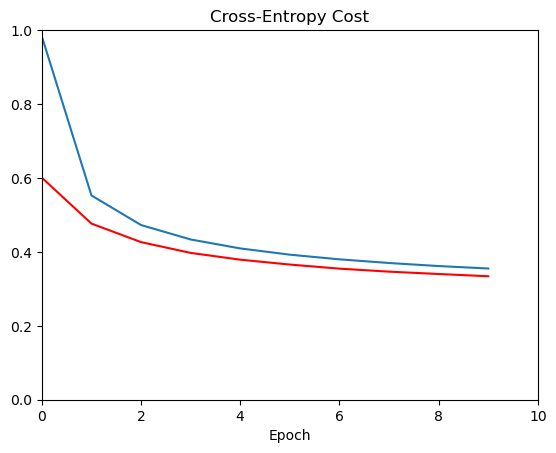

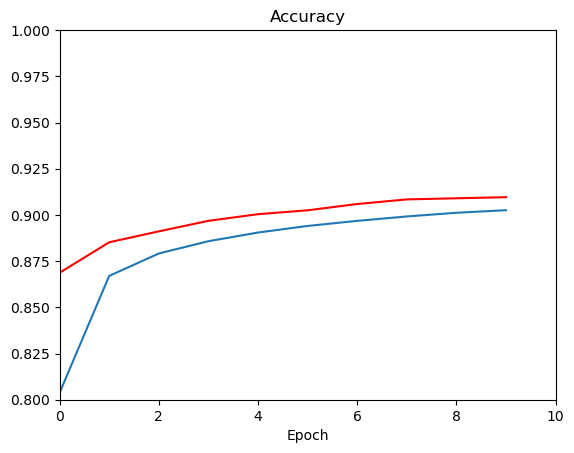

In [20]:
plot_training(nepochs, cost_hist, cost_hist_test, acc_hist, acc_hist_test)

#### MLP

In [16]:
class MLP3HiddenLayers(torch.nn.Module):
    
    def __init__(self, ninput=28*28, nhidden1 = 200, nhidden2 = 100, nhidden3= 50, noutput=10):
        super(MLP3HiddenLayers, self).__init__()
        self.layers = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(ninput,nhidden1),
            torch.nn.ReLU(),
            torch.nn.Linear(nhidden1, nhidden2),
            torch.nn.ReLU(),
            torch.nn.Linear(nhidden2, nhidden3),
            torch.nn.ReLU(),
            torch.nn.Linear(nhidden3, noutput),
        ) 
    
    def forward(self, x):
        z = self.layers(x)
        return z


In [17]:
model = MLP3HiddenLayers(ninput=28*28, nhidden1=200, nhidden2=100, nhidden3=50, noutput=10)
print(model)

MLP3HiddenLayers(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=200, bias=True)
    (2): ReLU()
    (3): Linear(in_features=200, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=50, bias=True)
    (6): ReLU()
    (7): Linear(in_features=50, out_features=10, bias=True)
  )
)


In [18]:
summary(model, (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 200]         157,000
              ReLU-3                  [-1, 200]               0
            Linear-4                  [-1, 100]          20,100
              ReLU-5                  [-1, 100]               0
            Linear-6                   [-1, 50]           5,050
              ReLU-7                   [-1, 50]               0
            Linear-8                   [-1, 10]             510
Total params: 182,660
Trainable params: 182,660
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.70
Estimated Total Size (MB): 0.71
----------------------------------------------------------------


In [19]:
nbatch = 64
nepochs = 10
learning_rate = 0.01

cost_hist = []
cost_hist_test = []
acc_hist = []
acc_hist_test = []

model = MLP3HiddenLayers(ninput=28*28, nhidden1=200, nhidden2=100, nhidden3=50, noutput=10)
cost_ce = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

training_loader = DataLoader(training_data, batch_size=nbatch, shuffle=True)
test_loader = DataLoader(test_data, batch_size=10000, shuffle=True)
size = len(training_loader.dataset)
nbatches = len(training_loader)

Xtest, Ytest = next(iter(test_loader))

for epoch in range(nepochs):
    cost, acc = 0.0, 0.0
    for batch, (X, Y) in enumerate(training_loader):
        pred = model(X)
        loss = cost_ce(pred, Y)
        cost += loss.item()
        acc += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()

        # gradient, parameter update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    cost /= nbatches
    acc /= size
    
    with torch.no_grad():
        pred = model(Xtest)
        cost_test = cost_ce(pred, Ytest).item()
        acc_test = (pred.argmax(dim=1) == Ytest).type(torch.float).mean().item()
    print("Epoch %i: %f, %f, %f, %f"%(epoch, cost, acc, cost_test, acc_test))
    cost_hist.append(cost)
    cost_hist_test.append(cost_test)
    acc_hist.append(acc)
    acc_hist_test.append(acc_test)


Epoch 0: 2.247060, 0.253067, 2.048425, 0.410900
Epoch 1: 1.228996, 0.660683, 0.631476, 0.815200
Epoch 2: 0.501836, 0.858100, 0.409827, 0.881700
Epoch 3: 0.382901, 0.890450, 0.353311, 0.896200
Epoch 4: 0.335394, 0.903700, 0.305534, 0.910500
Epoch 5: 0.302280, 0.913467, 0.276442, 0.920100
Epoch 6: 0.274229, 0.921833, 0.257420, 0.925900
Epoch 7: 0.249376, 0.928617, 0.237436, 0.929100
Epoch 8: 0.226574, 0.935133, 0.213789, 0.937400
Epoch 9: 0.207415, 0.939583, 0.197132, 0.943400


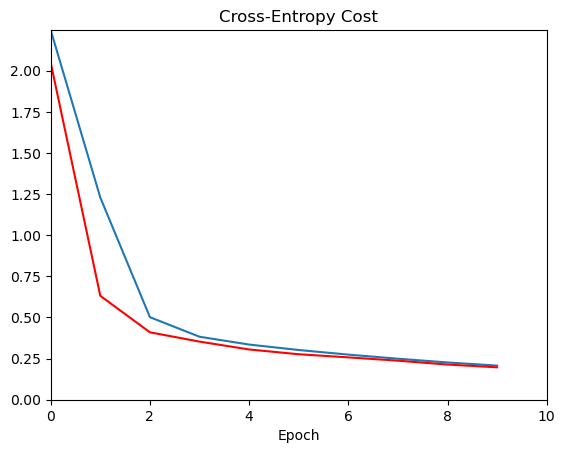

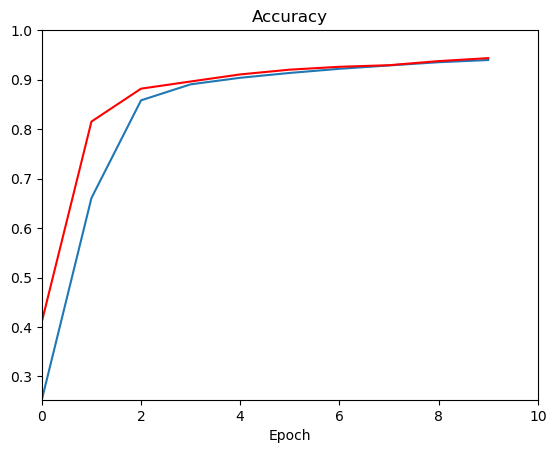

In [20]:
plot_training(nepochs, cost_hist, cost_hist_test, acc_hist, acc_hist_test)

#### Hyper-Parameter Tuning

Modify learning rate, batchsize, number of layers and units per layer and explore what changes these modification have on performance (train and test accuracy).

...